# EE/CS5841 Final Project: Software-Based Signal Denoising

This notebook trains neural-network models to approximate an expensive hardware noise fix in software.

Correct supervised setup:

- `Sample 2` = original noisy signal
- `ExpectedA` = signal after expensive hardware fix, used as the clean target
- `Expected` = DC average/reference value, used only as a baseline/reference

The main model learns a residual correction:

`predicted_clean = noisy_signal + predicted_correction`


In [1]:
# ============================================
# 0. Setup
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Load data from Google Drive

The project dataset should contain at least these columns: `Sample 2`, `Expected`, and `ExpectedA`.


In [2]:
# ============================================
# 1. Load Excel data
# ============================================

from google.colab import drive, files
import pandas as pd
import os

drive.mount('/content/drive')

# Update this path if the file location/name changes.
file_path = '/content/drive/Shareddrives/5841 - Final Project/Sample_Data_1.xlsx'

print("Using file:", file_path)
print("File exists:", os.path.exists(file_path))

# Fallback: upload manually if the Drive path is not available.
if not os.path.exists(file_path):
    print("Drive file not found. Please upload the Excel file manually.")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]
    print("Uploaded file:", file_path)

sheets = pd.read_excel(file_path, sheet_name=None)

for name, sheet in sheets.items():
    print("\nSheet:", name)
    print("Shape:", sheet.shape)
    print(sheet.head())

# Select working sheet.
df = pd.read_excel(file_path, sheet_name="Sheet1")

print("\nSelected Sheet1")
print(df.head())
print(df.columns)
print(df.shape)


Mounted at /content/drive
Using file: /content/drive/Shareddrives/5841 - Final Project/Sample_Data_1.xlsx
File exists: True

Sheet: Sheet1
Shape: (2501, 8)
   Sample 2  Expected  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0  2.465201  2.445942         NaN         NaN         NaN         NaN   
1  2.148962  2.445942         NaN         NaN         NaN         NaN   
2  2.467643  2.445942         NaN         NaN         NaN         NaN   
3  2.467643  2.445942         NaN         NaN         NaN         NaN   
4  2.466422  2.445942         NaN         NaN         NaN         NaN   

   Unnamed: 6  ExpectedA  
0         NaN   2.467643  
1         NaN   2.465201  
2         NaN   2.465201  
3         NaN   2.465201  
4         NaN   2.462759  

Sheet: Sheet2
Shape: (10798, 14)
   Sample 2  Expected  Unnamed: 2  Unnamed: 3  Unnamed: 4  Expected.1  \
0  2.465201  2.467643         NaN         NaN         NaN    2.445942   
1  2.148962  2.465201         NaN         NaN         NaN    2.

## Select noisy signal, clean target, and DC reference

This is the corrected project setup:

- `Sample 2` is the original noisy signal.
- `ExpectedA` is the clean signal after the expensive hardware fix. This is the supervised target.
- `Expected` is the DC average/reference value. This is useful as a baseline but is not the main target.


In [3]:
# ============================================
# 2. Select columns
# ============================================

df.columns = df.columns.astype(str).str.strip()

NOISY_COL = "Sample 2"
TARGET_COL = "ExpectedA"      # clean signal after expensive hardware fix
REFERENCE_COL = "Expected"    # DC average/reference value

required_cols = [NOISY_COL, TARGET_COL, REFERENCE_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()
df.columns = ["noisy", "clean_fixed", "dc_expected"]

for col in ["noisy", "clean_fixed", "dc_expected"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

print(df.head())
print(df.describe())

print("\nTarget clarification:")
print("Input  : noisy = Sample 2")
print("Target : clean_fixed = ExpectedA")
print("Baseline/reference only: dc_expected = Expected")


      noisy  clean_fixed  dc_expected
0  2.465201     2.467643     2.445942
1  2.148962     2.465201     2.445942
2  2.467643     2.465201     2.445942
3  2.467643     2.465201     2.445942
4  2.466422     2.462759     2.445942
             noisy  clean_fixed   dc_expected
count  2501.000000  2501.000000  2.501000e+03
mean      2.445942     2.465551  2.445942e+00
std       0.069662     0.004771  9.017178e-14
min       2.026862     2.424908  2.445942e+00
25%       2.463980     2.465201  2.445942e+00
50%       2.465201     2.465201  2.445942e+00
75%       2.466422     2.466422  2.445942e+00
max       2.637362     2.504273  2.445942e+00

Target clarification:
Input  : noisy = Sample 2
Target : clean_fixed = ExpectedA
Baseline/reference only: dc_expected = Expected


## Plot the raw signal

This plot checks whether the noisy signal, hardware-fixed clean signal, and DC reference are aligned and usable.


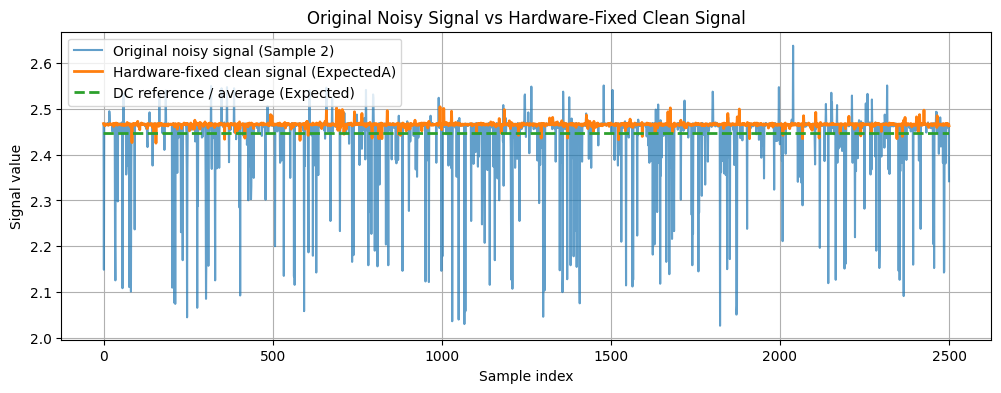

In [4]:
# ============================================
# 3. Plot noisy, hardware-fixed clean, and DC reference
# ============================================

plt.figure(figsize=(12, 4))
plt.plot(df["noisy"].values, label="Original noisy signal (Sample 2)", alpha=0.7)
plt.plot(df["clean_fixed"].values, label="Hardware-fixed clean signal (ExpectedA)", linewidth=2)
plt.plot(df["dc_expected"].values, label="DC reference / average (Expected)", linestyle="--", linewidth=2)
plt.xlabel("Sample index")
plt.ylabel("Signal value")
plt.title("Original Noisy Signal vs Hardware-Fixed Clean Signal")
plt.legend()
plt.grid(True)
plt.show()


## Baseline error before modeling

The raw noisy signal and the DC reference are evaluated against `ExpectedA`, the hardware-fixed clean signal.


In [5]:
# ============================================
# 4. Baseline metrics
# ============================================

def regression_metrics(y_true, y_pred, label="Model"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{label}")
    print(f"  MSE : {mse:.8f}")
    print(f"  RMSE: {rmse:.8f}")
    print(f"  MAE : {mae:.8f}")

    return {"mse": mse, "rmse": rmse, "mae": mae}

y_true_raw = df["clean_fixed"].values
raw_noisy = df["noisy"].values
dc_reference = df["dc_expected"].values

raw_metrics_full = regression_metrics(y_true_raw, raw_noisy, label="Raw noisy signal vs ExpectedA")
dc_metrics_full = regression_metrics(y_true_raw, dc_reference, label="DC reference vs ExpectedA")


Raw noisy signal vs ExpectedA
  MSE : 0.00526394
  RMSE: 0.07255305
  MAE : 0.02417931
DC reference vs ExpectedA
  MSE : 0.00040725
  RMSE: 0.02018050
  MAE : 0.01978908


## Classical baseline: moving average

A moving average provides a simple traditional software-filter baseline. The neural networks should be compared against this, not only against the raw signal.


Moving Average window=5 vs ExpectedA
  MSE : 0.00154181
  RMSE: 0.03926585
  MAE : 0.02232592
Moving Average window=15 vs ExpectedA
  MSE : 0.00080003
  RMSE: 0.02828486
  MAE : 0.02083024


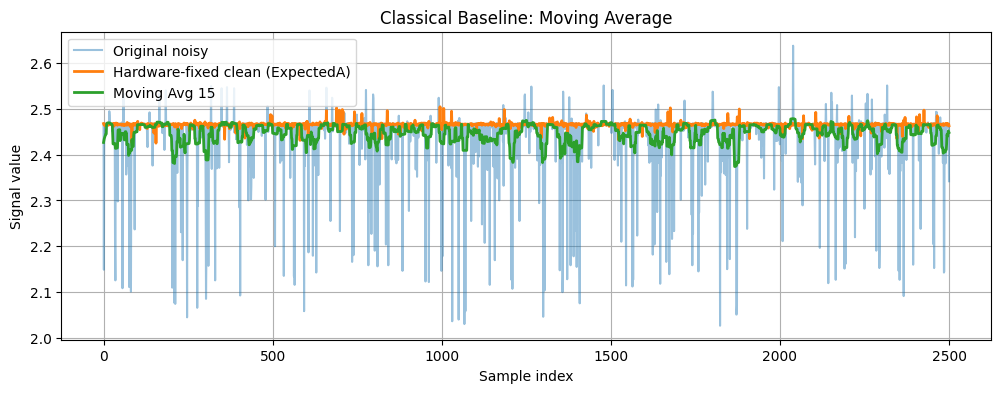

In [6]:
# ============================================
# 5. Moving average baselines
# ============================================

df["moving_avg_5"] = df["noisy"].rolling(window=5, center=True, min_periods=1).mean()
df["moving_avg_15"] = df["noisy"].rolling(window=15, center=True, min_periods=1).mean()

ma5_metrics_full = regression_metrics(df["clean_fixed"], df["moving_avg_5"], label="Moving Average window=5 vs ExpectedA")
ma15_metrics_full = regression_metrics(df["clean_fixed"], df["moving_avg_15"], label="Moving Average window=15 vs ExpectedA")

plt.figure(figsize=(12, 4))
plt.plot(df["noisy"].values, label="Original noisy", alpha=0.45)
plt.plot(df["clean_fixed"].values, label="Hardware-fixed clean (ExpectedA)", linewidth=2)
plt.plot(df["moving_avg_15"].values, label="Moving Avg 15", linewidth=2)
plt.xlabel("Sample index")
plt.ylabel("Signal value")
plt.title("Classical Baseline: Moving Average")
plt.legend()
plt.grid(True)
plt.show()


## Create windowed data

The model uses a sliding window of recent noisy samples as input. The target is the correction needed to turn the current noisy sample into the hardware-fixed signal:

`correction = ExpectedA - Sample 2`


In [7]:
# ============================================
# 6. Create sliding windows
# ============================================

def create_windows(noisy, clean_fixed, dc_expected, ma5, ma15, window_size=32):
    X = []
    y_correction = []
    y_clean = []
    current_noisy = []
    current_dc = []
    current_ma5 = []
    current_ma15 = []

    for i in range(window_size - 1, len(noisy)):
        window = noisy[i - window_size + 1 : i + 1]
        correction = clean_fixed[i] - noisy[i]

        X.append(window)
        y_correction.append(correction)
        y_clean.append(clean_fixed[i])
        current_noisy.append(noisy[i])
        current_dc.append(dc_expected[i])
        current_ma5.append(ma5[i])
        current_ma15.append(ma15[i])

    return (
        np.array(X),
        np.array(y_correction),
        np.array(y_clean),
        np.array(current_noisy),
        np.array(current_dc),
        np.array(current_ma5),
        np.array(current_ma15),
    )

WINDOW_SIZE = 32

X, y_corr, y_clean, current_noisy, current_dc, current_ma5, current_ma15 = create_windows(
    df["noisy"].values,
    df["clean_fixed"].values,
    df["dc_expected"].values,
    df["moving_avg_5"].values,
    df["moving_avg_15"].values,
    window_size=WINDOW_SIZE
)

print("X shape:", X.shape)
print("Correction target shape:", y_corr.shape)
print("Clean target shape:", y_clean.shape)
print("First correction example:", y_corr[0])


X shape: (2470, 32)
Correction target shape: (2470,)
Clean target shape: (2470,)
First correction example: 0.002441883549929802


## Train / validation / test split

A chronological split is used because this is signal data. This avoids training on future samples and testing on earlier samples.


In [8]:
# ============================================
# 7. Chronological train/val/test split
# ============================================

n = len(X)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

y_train = y_corr[:train_end]
y_val = y_corr[train_end:val_end]
y_test = y_corr[val_end:]

clean_train = y_clean[:train_end]
clean_val = y_clean[train_end:val_end]
clean_test = y_clean[val_end:]

noisy_train = current_noisy[:train_end]
noisy_val = current_noisy[train_end:val_end]
noisy_test = current_noisy[val_end:]

dc_train = current_dc[:train_end]
dc_val = current_dc[train_end:val_end]
dc_test = current_dc[val_end:]

ma5_train = current_ma5[:train_end]
ma5_val = current_ma5[train_end:val_end]
ma5_test = current_ma5[val_end:]

ma15_train = current_ma15[:train_end]
ma15_val = current_ma15[train_end:val_end]
ma15_test = current_ma15[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (1729, 32) (1729,)
Val:   (370, 32) (370,)
Test:  (371, 32) (371,)


## Scale the data correctly

The scalers are fit on the training set only. The same scaler constants must later be exported if the model is deployed to STM32.


In [9]:
# ============================================
# 8. Scaling
# ============================================

x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Flatten windows for scaling.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_train_s = x_scaler.fit_transform(X_train_flat).astype("float32")
X_val_s = x_scaler.transform(X_val_flat).astype("float32")
X_test_s = x_scaler.transform(X_test_flat).astype("float32")

y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel().astype("float32")
y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel().astype("float32")
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel().astype("float32")

print("Scaled X train:", X_train_s.shape, X_train_s.dtype)
print("Scaled y train:", y_train_s.shape, y_train_s.dtype)
print("Input scaler mean shape:", x_scaler.mean_.shape)
print("Input scaler scale shape:", x_scaler.scale_.shape)
print("Output scaler mean:", y_scaler.mean_)
print("Output scaler scale:", y_scaler.scale_)


Scaled X train: (1729, 32) float32
Scaled y train: (1729,) float32
Input scaler mean shape: (32,)
Input scaler scale shape: (32,)
Output scaler mean: [0.02080576]
Output scaler scale: [0.07224825]


## Model 1: DNN / MLP residual model

This model predicts the correction needed to transform the noisy signal into the hardware-fixed signal.


In [10]:
# ============================================
# 9. Build DNN / MLP residual model
# ============================================

def build_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # predicted correction
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

mlp_model = build_mlp(X_train_s.shape[1])
mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,385 (32.75 KB)

 Trainable params: 8,385 (32.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model 1


Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.5986 - mae: 0.4362 - rmse: 0.7737 - val_loss: 0.1589 - val_mae: 0.2656 - val_rmse: 0.3986 - learning_rate: 0.0010
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1257 - mae: 0.2575 - rmse: 0.3545 - val_loss: 0.0805 - val_mae: 0.1903 - val_rmse: 0.2837 - learning_rate: 0.0010
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0631 - mae: 0.1820 - rmse: 0.2512 - val_loss: 0.0595 - val_mae: 0.1593 - val_rmse: 0.2439 - learning_rate: 0.0010
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0409 - mae: 0.1479 - rmse: 0.2023 - val_loss: 0.0525 - val_mae: 0.1453 - val_rmse: 0.2292 - learning_rate: 0.0010
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0312 - mae: 0.1287 - rmse: 0.1766 - val_loss: 0.0474 - val_mae: 0.1370 - val_rmse: 0.2177 - learning_rate: 0.0010
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0246 - mae: 0.1144 - rmse: 0.1567 - val_loss: 0.0439 - val_mae:

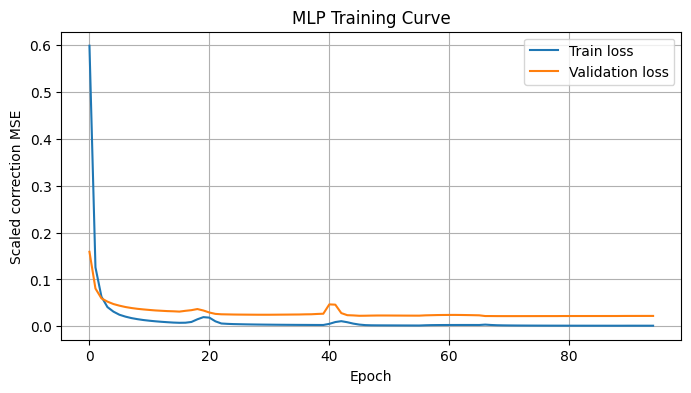

In [11]:
# ============================================
# 10. Train MLP
# ============================================

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
]

history_mlp = mlp_model.fit(
    X_train_s,
    y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history["loss"], label="Train loss")
plt.plot(history_mlp.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Scaled correction MSE")
plt.title("MLP Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## Evaluate Model 1


In [12]:
# ============================================
# 11. Evaluate MLP
# ============================================

def evaluate_residual_model(model, X_s, noisy_current, y_clean_true, y_scaler, label):
    pred_corr_s = model.predict(X_s, verbose=0).reshape(-1, 1)
    pred_corr = y_scaler.inverse_transform(pred_corr_s).ravel()

    pred_clean = noisy_current + pred_corr

    metrics = regression_metrics(y_clean_true, pred_clean, label=label)

    return pred_clean, pred_corr, metrics

mlp_pred_clean, mlp_pred_corr, mlp_metrics = evaluate_residual_model(
    mlp_model,
    X_test_s,
    noisy_test,
    clean_test,
    y_scaler,
    label="MLP residual model vs ExpectedA"
)


MLP residual model vs ExpectedA
  MSE : 0.00010682
  RMSE: 0.01033538
  MAE : 0.00748038


## Plot Model 1 result


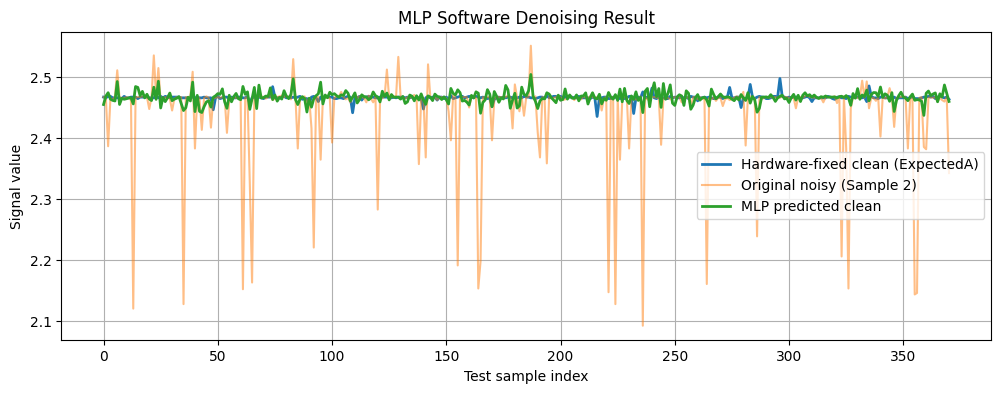

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(clean_test, label="Hardware-fixed clean (ExpectedA)", linewidth=2)
plt.plot(noisy_test, label="Original noisy (Sample 2)", alpha=0.5)
plt.plot(mlp_pred_clean, label="MLP predicted clean", linewidth=2)
plt.xlabel("Test sample index")
plt.ylabel("Signal value")
plt.title("MLP Software Denoising Result")
plt.legend()
plt.grid(True)
plt.show()


## Model 2: Lightweight 1D CNN

The 1D CNN sees the window as a short sequence of signal samples. This can help if nearby samples contain useful noise patterns.


In [14]:
# ============================================
# 12. Prepare data for 1D CNN
# ============================================

X_train_cnn = X_train_s.reshape(X_train_s.shape[0], WINDOW_SIZE, 1).astype("float32")
X_val_cnn = X_val_s.reshape(X_val_s.shape[0], WINDOW_SIZE, 1).astype("float32")
X_test_cnn = X_test_s.reshape(X_test_s.shape[0], WINDOW_SIZE, 1).astype("float32")

print("CNN train shape:", X_train_cnn.shape)


CNN train shape: (1729, 32, 1)


## Build Model 2


In [15]:
# ============================================
# 13. Build lightweight 1D CNN
# ============================================

def build_1d_cnn(window_size):
    inputs = keras.Input(shape=(window_size, 1))

    x = layers.Conv1D(16, kernel_size=3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)  # predicted correction

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

cnn_model = build_1d_cnn(WINDOW_SIZE)
cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 16)         │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 32, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 96 (384.00 B)

## Train Model 2


In [16]:
# ============================================
# 14. Train 1D CNN
# ============================================

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_s,
    validation_data=(X_val_cnn, y_val_s),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.9518 - mae: 0.5136 - rmse: 0.9756 - val_loss: 0.6688 - val_mae: 0.4497 - val_rmse: 0.8178 - learning_rate: 0.0010
Epoch 2/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5113 - mae: 0.3723 - rmse: 0.7150 - val_loss: 0.5737 - val_mae: 0.4128 - val_rmse: 0.7574 - learning_rate: 0.0010
Epoch 3/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1006 - mae: 0.2030 - rmse: 0.3172 - val_loss: 0.4702 - val_mae: 0.3956 - val_rmse: 0.6857 - learning_rate: 0.0010
Epoch 4/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0582 - mae: 0.1525 - rmse: 0.2412 - val_loss: 0.4096 - val_mae: 0.3734 - val_rmse: 0.6400 - learning_rate: 0.0010
Epoch 5/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0461 - mae: 0.1361 - rmse: 0.2148 - val_loss: 0.3424 - val_mae: 0.3374 - val_rmse: 0.5851 - learning_rate: 0.0010
Epoch 6/300
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0379 - mae: 0.1239 - rmse: 0.1946 - val_loss: 0.2762 - val_ma

## Plot Model 2 training curve


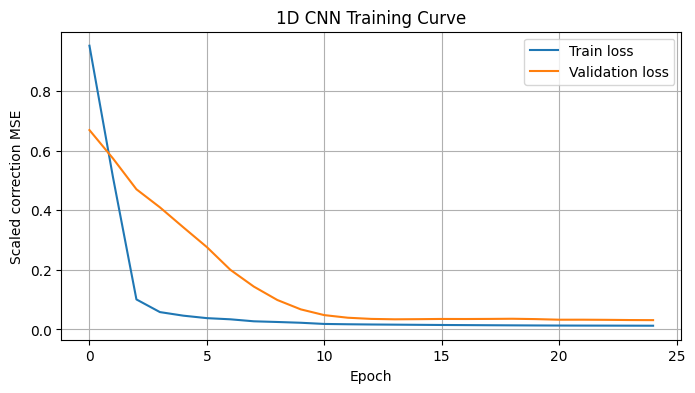

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history_cnn.history["loss"], label="Train loss")
plt.plot(history_cnn.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Scaled correction MSE")
plt.title("1D CNN Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## Evaluate Model 2


1D CNN residual model vs ExpectedA
  MSE : 0.00460786
  RMSE: 0.06788125
  MAE : 0.03808598


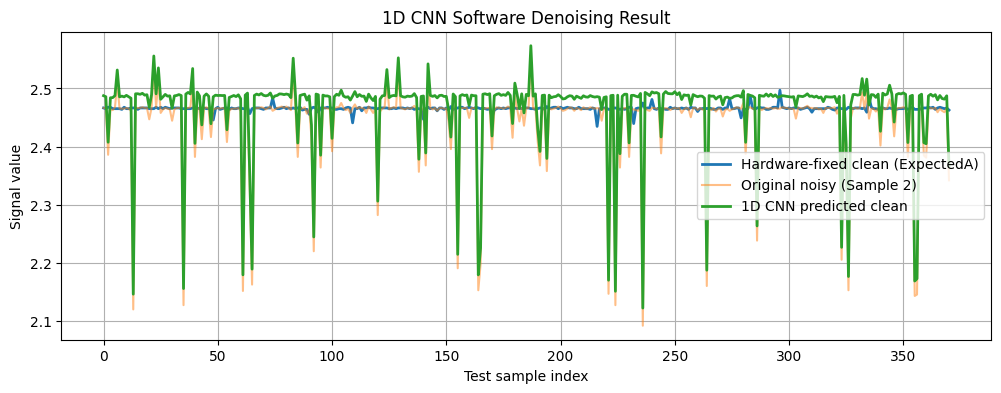

In [18]:
# ============================================
# 15. Evaluate 1D CNN
# ============================================

cnn_pred_clean, cnn_pred_corr, cnn_metrics = evaluate_residual_model(
    cnn_model,
    X_test_cnn,
    noisy_test,
    clean_test,
    y_scaler,
    label="1D CNN residual model vs ExpectedA"
)

plt.figure(figsize=(12, 4))
plt.plot(clean_test, label="Hardware-fixed clean (ExpectedA)", linewidth=2)
plt.plot(noisy_test, label="Original noisy (Sample 2)", alpha=0.5)
plt.plot(cnn_pred_clean, label="1D CNN predicted clean", linewidth=2)
plt.xlabel("Test sample index")
plt.ylabel("Signal value")
plt.title("1D CNN Software Denoising Result")
plt.legend()
plt.grid(True)
plt.show()


## Compare all models

All models are compared against `ExpectedA`, the hardware-fixed clean signal.


In [19]:
# ============================================
# 16. Model comparison on test set
# ============================================

test_raw_metrics = regression_metrics(clean_test, noisy_test, "Raw noisy test vs ExpectedA")
test_dc_metrics = regression_metrics(clean_test, dc_test, "DC reference test vs ExpectedA")
test_ma5_metrics = regression_metrics(clean_test, ma5_test, "Moving average 5 test vs ExpectedA")
test_ma15_metrics = regression_metrics(clean_test, ma15_test, "Moving average 15 test vs ExpectedA")

comparison = pd.DataFrame([
    {"Model": "Raw noisy signal", **test_raw_metrics},
    {"Model": "DC reference / average", **test_dc_metrics},
    {"Model": "Moving average window=5", **test_ma5_metrics},
    {"Model": "Moving average window=15", **test_ma15_metrics},
    {"Model": "MLP residual model", **mlp_metrics},
    {"Model": "1D CNN residual model", **cnn_metrics},
])

comparison = comparison.sort_values("rmse").reset_index(drop=True)
comparison


Raw noisy test vs ExpectedA
  MSE : 0.00510442
  RMSE: 0.07144522
  MAE : 0.02519340
DC reference test vs ExpectedA
  MSE : 0.00040467
  RMSE: 0.02011635
  MAE : 0.01976214
Moving average 5 test vs ExpectedA
  MSE : 0.00149144
  RMSE: 0.03861917
  MAE : 0.02251841
Moving average 15 test vs ExpectedA
  MSE : 0.00072948
  RMSE: 0.02700895
  MAE : 0.02041752


,Model,mse,rmse,mae
0,MLP residual model,0.000107,0.010335,0.007480
1,DC reference / average,0.000405,0.020116,0.019762
2,Moving average window=15,0.000729,0.027009,0.020418
3,Moving average window=5,0.001491,0.038619,0.022518
4,1D CNN residual model,0.004608,0.067881,0.038086
5,Raw noisy signal,0.005104,0.071445,0.025193


## SNR improvement

SNR is computed using `ExpectedA` as the clean reference. Higher SNR means the estimate is closer to the hardware-fixed signal.


In [20]:
# ============================================
# 17. SNR improvement
# ============================================

def snr_db(clean, estimate):
    noise = clean - estimate
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    if noise_power == 0:
        return np.inf
    return 10 * np.log10(signal_power / noise_power)

raw_snr = snr_db(clean_test, noisy_test)
dc_snr = snr_db(clean_test, dc_test)
ma15_snr = snr_db(clean_test, ma15_test)
mlp_snr = snr_db(clean_test, mlp_pred_clean)
cnn_snr = snr_db(clean_test, cnn_pred_clean)

print(f"Raw noisy SNR:       {raw_snr:.2f} dB")
print(f"DC reference SNR:    {dc_snr:.2f} dB")
print(f"Moving Avg 15 SNR:   {ma15_snr:.2f} dB")
print(f"MLP SNR:             {mlp_snr:.2f} dB")
print(f"1D CNN SNR:          {cnn_snr:.2f} dB")

print("\nImprovement over raw noisy signal:")
print(f"Moving Avg 15: {ma15_snr - raw_snr:.2f} dB")
print(f"MLP:           {mlp_snr - raw_snr:.2f} dB")
print(f"1D CNN:        {cnn_snr - raw_snr:.2f} dB")


Raw noisy SNR:       30.76 dB
DC reference SNR:    41.77 dB
Moving Avg 15 SNR:   39.21 dB
MLP SNR:             47.55 dB
1D CNN SNR:          31.20 dB

Improvement over raw noisy signal:
Moving Avg 15: 8.45 dB
MLP:           16.79 dB
1D CNN:        0.44 dB


## Measure approximate Colab inference time

This gives a rough software timing estimate. It is not the same as STM32 runtime. STM32 runtime should be measured later on the board using a hardware timer/cycle counter.


In [21]:
# ============================================
# 18. Inference time test in Colab
# ============================================

def measure_inference_time(model, X_sample, repeats=1000):
    sample = tf.convert_to_tensor(X_sample[:1], dtype=tf.float32)

    # Warmup
    _ = model(sample, training=False)

    start = time.time()
    for _ in range(repeats):
        _ = model(sample, training=False)
    end = time.time()

    avg_time = (end - start) / repeats
    print(f"Average inference time: {avg_time * 1000:.4f} ms per sample/window")
    return avg_time

print("MLP inference time:")
mlp_time = measure_inference_time(mlp_model, X_test_s, repeats=1000)

print("1D CNN inference time:")
cnn_time = measure_inference_time(cnn_model, X_test_cnn, repeats=1000)


MLP inference time:
Average inference time: 4.4660 ms per sample/window
1D CNN inference time:
Average inference time: 12.6983 ms per sample/window


## Save best model

The best model is selected automatically based on test RMSE. This avoids accidentally saving the wrong model.


In [22]:
# ============================================
# 19. Save best model
# ============================================

from google.colab import files

if mlp_metrics["rmse"] <= cnn_metrics["rmse"]:
    best_model = mlp_model
    best_name = "mlp_residual_denoiser_expectedA"
    best_input_kind = "mlp"
    best_rmse = mlp_metrics["rmse"]
else:
    best_model = cnn_model
    best_name = "cnn_residual_denoiser_expectedA"
    best_input_kind = "cnn"
    best_rmse = cnn_metrics["rmse"]

best_model.save(f"{best_name}.keras")

print("Best model:", best_name)
print("Best model input kind:", best_input_kind)
print("Best model test RMSE:", best_rmse)
print("Saved model:", f"{best_name}.keras")


Best model: mlp_residual_denoiser_expectedA
Best model input kind: mlp
Best model test RMSE: 0.010335375547247849
Saved model: mlp_residual_denoiser_expectedA.keras


## Download best Keras model


In [23]:
from google.colab import files
files.download(f"{best_name}.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Convert best model to TensorFlow Lite

The `.tflite` file is the format to try with STM32Cube.AI or TensorFlow Lite Micro.


In [24]:
# ============================================
# 20. Convert best model to TensorFlow Lite
# ============================================

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

with open(f"{best_name}.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model size:", os.path.getsize(f"{best_name}.tflite"), "bytes")

files.download(f"{best_name}.tflite")


Saved artifact at '/tmp/tmpbwv9vti9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132686548672656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594087056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594087632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594088016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model size: 35796 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Optional quantized TFLite version

This creates a smaller model file. Deploy and validate the float TFLite model first, then try the quantized model as a bonus.


In [25]:
# ============================================
# 21. Quantized TFLite model
# ============================================

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_quant_model = converter.convert()

with open(f"{best_name}_quant.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("Quantized TFLite model size:", os.path.getsize(f"{best_name}_quant.tflite"), "bytes")

files.download(f"{best_name}_quant.tflite")


Saved artifact at '/tmp/tmp7226oet5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132686548672656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594087056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594087632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594085328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594088016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132685594086864: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite model size: 13200 bytes


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Export constants and test vectors for STM32

For board-side testing, STM32 must use the same input scaling and output unscaling as Colab. This cell prints C arrays for one test window and scaler constants. Paste these into your STM32 project when testing the model with hardcoded inputs.


In [26]:
# ============================================
# 22. Export scaler constants and one STM32 test vector
# ============================================

def c_array(name, values, dtype="float"):
    values = np.asarray(values).ravel()
    print(f"static const {dtype} {name}[{len(values)}] = {{")
    line = ""
    for i, v in enumerate(values):
        item = f"{float(v):.9f}f"
        if i < len(values) - 1:
            item += ", "
        line += item
        if (i + 1) % 6 == 0:
            print("    " + line)
            line = ""
    if line:
        print("    " + line)
    print("};\n")

idx = 0

# For MLP, use X_test_s[idx] as model input. For CNN, reshape it on STM32 if needed.
test_window_raw = X_test[idx]
test_window_scaled = X_test_s[idx]
test_current_noisy = noisy_test[idx]
test_clean_true = clean_test[idx]

if best_input_kind == "mlp":
    pred_corr_s = best_model.predict(X_test_s[idx:idx+1], verbose=0).reshape(-1, 1)
else:
    pred_corr_s = best_model.predict(X_test_cnn[idx:idx+1], verbose=0).reshape(-1, 1)

pred_corr = y_scaler.inverse_transform(pred_corr_s).ravel()[0]
pred_clean = test_current_noisy + pred_corr

print("// ===== STM32 Test Vector Info =====")
print(f"#define WINDOW_SIZE {WINDOW_SIZE}")
print(f"// best_name = {best_name}")
print(f"// best_input_kind = {best_input_kind}")
print(f"// current_noisy = {test_current_noisy:.9f}f")
print(f"// true_clean_expectedA = {test_clean_true:.9f}f")
print(f"// colab_predicted_correction = {pred_corr:.9f}f")
print(f"// colab_predicted_clean = {pred_clean:.9f}f")
print()

c_array("x_mean", x_scaler.mean_)
c_array("x_scale", x_scaler.scale_)
print(f"static const float y_mean = {float(y_scaler.mean_[0]):.9f}f;")
print(f"static const float y_scale = {float(y_scaler.scale_[0]):.9f}f;\n")

c_array("test_window_raw", test_window_raw)
c_array("test_window_scaled", test_window_scaled)
print(f"static const float test_current_noisy = {test_current_noisy:.9f}f;")
print(f"static const float test_clean_expectedA = {test_clean_true:.9f}f;")
print(f"static const float colab_predicted_clean = {pred_clean:.9f}f;")


// ===== STM32 Test Vector Info =====
#define WINDOW_SIZE 32
// best_name = mlp_residual_denoiser_expectedA
// best_input_kind = mlp
// current_noisy = 2.466422081f
// true_clean_expectedA = 2.466422081f
// colab_predicted_correction = -0.012150692f
// colab_predicted_clean = 2.454271389f

static const float x_mean[32] = {
    2.445220185f, 2.445203943f, 2.445386140f, 2.445384727f, 2.445383315f, 2.445383315f, 
    2.445384021f, 2.445383315f, 2.445383315f, 2.445384021f, 2.445384021f, 2.445270325f, 
    2.445271031f, 2.445091659f, 2.445091659f, 2.444954658f, 2.444955364f, 2.444951127f, 
    2.444934179f, 2.444922880f, 2.444921467f, 2.444910875f, 2.444910875f, 2.444911581f, 
    2.444912287f, 2.444910168f, 2.444910168f, 2.444918643f, 2.444923586f, 2.444922880f, 
    2.444932060f, 2.444745626f
};

static const float x_scale[32] = {
    0.071345306f, 0.071343952f, 0.070988541f, 0.070988122f, 0.070987704f, 0.070987704f, 
    0.070987883f, 0.070987667f, 0.070987667f, 0.070987870f, 0.070987870

## Short interpretation for report

Use this wording after rerunning the notebook:

The project uses `Sample 2` as the original noisy signal and `ExpectedA` as the hardware-fixed clean target. The neural network predicts a residual correction so the software output can approximate the expensive hardware fix. The `Expected` column is treated only as a DC reference/baseline, not as the supervised target. Model performance should be judged by RMSE, MAE, SNR improvement, and inference-time feasibility compared with the raw noisy signal and simple filtering baselines.
